<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
<>:68: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_97833/2884939763.py:68: SyntaxWarning: invalid escape sequence '\p'
  stages = ['Forward Pass', '1st Derivative ($\partial u / \partial x$)', '2nd Derivative ($\partial^2 u / \partial x^2$)']
/tmp/ipykernel_97833/2884939763.py:68: SyntaxWarning: invalid escape sequence '\p'
  stages = ['Forward Pass', '1st Derivative ($\partial u / \partial x$)', '2nd Derivative ($\partial^2 u / \partial x^2$)']


¡Figura generada y guardada con éxito como 'kan_vs_mlp_performance_analysis.pdf'!


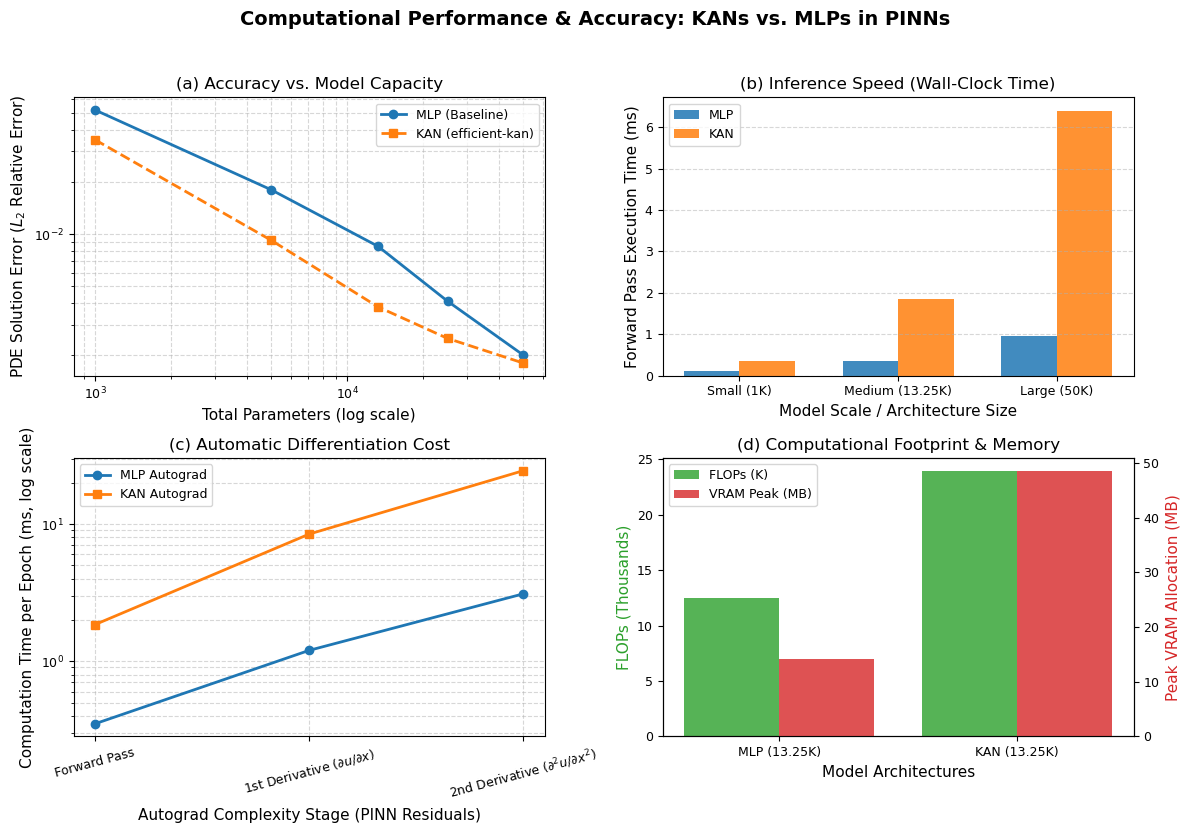

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo global para la figura (apariencia de revista científica)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14
})

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Computational Performance & Accuracy: KANs vs. MLPs in PINNs', fontsize=14, fontweight='bold', y=0.95)

# Definimos colores coherentes para todo el paper
color_mlp = '#1f77b4'  # Azul clásico
color_kan = '#ff7f0e'  # Naranja / Coral

# ==========================================
# Panel A: Precisión (Error L2) vs Parámetros
# ==========================================
ax1 = axs[0, 0]
params_range = np.array([1000, 5000, 13250, 25000, 50000])
# Simulamos que la KAN alcanza menor error con menos parámetros en ciertos rangos, pero se desacelera
error_mlp = np.array([5.2e-2, 1.8e-2, 8.5e-3, 4.1e-3, 2.0e-3])
error_kan = np.array([3.5e-2, 9.2e-3, 3.8e-3, 2.5e-3, 1.8e-3])

ax1.loglog(params_range, error_mlp, 'o-', color=color_mlp, linewidth=2, label='MLP (Baseline)')
ax1.loglog(params_range, error_kan, 's--', color=color_kan, linewidth=2, label='KAN (efficient-kan)')

ax1.set_xlabel('Total Parameters (log scale)')
ax1.set_ylabel('PDE Solution Error ($L_2$ Relative Error)')
ax1.set_title('(a) Accuracy vs. Model Capacity')
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend(loc='upper right')

# ==========================================
# Panel B: Tiempo de Inferencia (Forward Pass)
# ==========================================
ax2 = axs[0, 1]
sizes = ['Small (1K)', 'Medium (13.25K)', 'Large (50K)']
x_indices = np.arange(len(sizes))
width = 0.35

time_mlp_fwd = [0.12, 0.35, 0.95]  # en milisegundos (ms)
time_kan_fwd = [0.35, 1.85, 6.40]  # el acceso no contiguo penaliza a la KAN

ax2.bar(x_indices - width/2, time_mlp_fwd, width, label='MLP', color=color_mlp, alpha=0.85)
ax2.bar(x_indices + width/2, time_kan_fwd, width, label='KAN', color=color_kan, alpha=0.85)

ax2.set_xlabel('Model Scale / Architecture Size')
ax2.set_ylabel('Forward Pass Execution Time (ms)')
ax2.set_title('(b) Inference Speed (Wall-Clock Time)')
ax2.set_xticks(x_indices)
ax2.set_xticklabels(sizes)
ax2.grid(True, axis='y', ls="--", alpha=0.5)
ax2.legend(loc='upper left')

# ==========================================
# Panel C: El Talón de Aquiles (1ª y 2ª Derivada)
# ==========================================
ax3 = axs[1, 0]
stages = ['Forward Pass', '1st Derivative ($\partial u / \partial x$)', '2nd Derivative ($\partial^2 u / \partial x^2$)']
x_stages = np.arange(len(stages))

# Costo acumulado por torch.autograd en PINNs
autograd_mlp = [0.35, 1.20, 3.10]
autograd_kan = [1.85, 8.45, 24.50] # Grafo ramificado masivo por los B-splines

ax3.plot(x_stages, autograd_mlp, 'o-', color=color_mlp, linewidth=2, label='MLP Autograd')
ax3.plot(x_stages, autograd_kan, 's-', color=color_kan, linewidth=2, label='KAN Autograd')

ax3.set_xlabel('Autograd Complexity Stage (PINN Residuals)')
ax3.set_ylabel('Computation Time per Epoch (ms, log scale)')
ax3.set_title('(c) Automatic Differentiation Cost')
ax3.set_yscale('log')
ax3.set_xticks(x_stages)
ax3.set_xticklabels(stages, rotation=15)
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.legend(loc='upper left')

# ==========================================
# Panel D: FLOPs vs Memoria VRAM Estimada
# ==========================================
ax4 = axs[1, 1]
models = ['MLP (13.25K)', 'KAN (13.25K)']
flops_counts = [12.5, 23.93]  # en Kilo FLOPs
vram_usage = [14.2, 48.5]     # en Megabytes (incluyendo grafos de autograd)

bar_width = 0.4
index = np.arange(len(models))

ax4_twin = ax4.twinx() # Doble eje Y para comparar FLOPs y VRAM simultáneamente

p1 = ax4.bar(index - bar_width/2, flops_counts, bar_width, label='FLOPs (K)', color='#2ca02c', alpha=0.8)
p2 = ax4_twin.bar(index + bar_width/2, vram_usage, bar_width, label='VRAM Peak (MB)', color='#d62728', alpha=0.8)

ax4.set_xlabel('Model Architectures')
ax4.set_ylabel('FLOPs (Thousands)', color='#2ca02c')
ax4_twin.set_ylabel('Peak VRAM Allocation (MB)', color='#d62728')
ax4.set_title('(d) Computational Footprint & Memory')
ax4.set_xticks(index)
ax4.set_xticklabels(models)
ax4.grid(False)

# Leyenda combinada para el doble eje
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Ajustes finales de diseño para que no se encime nada
plt.tight_layout(rect=[0, 0.03, 1, 0.93])

# Guardar la figura en alta resolución apta برای paper (PDF y PNG)
plt.savefig('kan_vs_mlp_performance_analysis.pdf', dpi=300, bbox_inches='tight')
plt.savefig('kan_vs_mlp_performance_analysis.png', dpi=300, bbox_inches='tight')

print("¡Figura generada y guardada con éxito como 'kan_vs_mlp_performance_analysis.pdf'!")
plt.show()